# Bonus Experiments: Sampling Strategies + LSTM Visualization + Chinese Poetry

Run this AFTER completing the main experiments.

## 0. Setup - Load Environment and Previous Results

In [1]:
import torch
import json, os
from data_utils import TextDataset, download_shakespeare
from model import CharRNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load Shakespeare dataset
dataset_shakespeare = TextDataset(download_shakespeare(), val_fraction=0.1)

# Load previous results to find best model
results = []
for f in sorted(os.listdir('results')):
    if f.endswith('_result.json'):
        with open(os.path.join('results', f)) as fh:
            results.append(json.load(fh))

# Load best Shakespeare model
valid_results = [r for r in results if 'error' not in r]
best = min(valid_results, key=lambda r: r['best_val_loss'])
print(f'Best model: {best["name"]} (val_loss={best["best_val_loss"]:.4f})')

best_model_path = f"results/{best['name']}.pt"
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)

model = CharRNN(
    input_size=dataset_shakespeare.n_characters,
    hidden_size=best['config']['hidden_size'],
    output_size=dataset_shakespeare.n_characters,
    model_type=best['config']['model_type'],
    n_layers=best['config']['n_layers'],
    dropout=best['config'].get('dropout', 0.0)
).to(device)
model.load_state_dict(checkpoint['model_state'])
print('Model loaded!')

Device: cuda
Already exists: data/shakespeare.txt
Dataset: 1115394 chars, 65 unique
Train: 1003854 chars, Val: 111540 chars
Best model: hidden_512 (val_loss=1.5276)
Model loaded!


---
## Bonus 1: Sampling Strategy Comparison

Compare Greedy, Temperature, Top-k, Nucleus (Top-p), and combined Top-k+p sampling.
No retraining needed — uses the already trained best model.

In [2]:
from sampling_strategies import compare_sampling_strategies, print_sampling_comparison

sampling_results = compare_sampling_strategies(
    model, dataset_shakespeare, device,
    prime_str='ROMEO: ',
    predict_len=500,
    temperature=0.8
)

os.makedirs('figures_bonus', exist_ok=True)
print_sampling_comparison(sampling_results, save_path='figures_bonus/sampling_comparison.txt')

SAMPLING STRATEGY COMPARISON - DIVERSITY METRICS
Strategy                  Char Div   Bigram Rep   Word Div   Avg Word Len
------------------------------------------------------------------------------------------
Greedy                    0.0434     0.9190       0.1019     3.70        
Temperature (0.5)         0.0750     0.6660       0.7075     3.78        
Temperature (0.8)         0.0927     0.5395       0.7629     4.16        
Temperature (1.0)         0.1026     0.4783       0.8980     4.13        
Top-k (k=5)               0.0828     0.6324       0.6762     3.81        
Top-k (k=20)              0.0868     0.5988       0.8252     3.90        
Top-k (k=40)              0.0927     0.5830       0.8283     4.09        
Nucleus (p=0.5)           0.0651     0.7233       0.4737     3.46        
Nucleus (p=0.9)           0.0927     0.6225       0.7130     3.69        
Nucleus (p=0.95)          0.0927     0.5672       0.8095     3.80        
Top-k+p (k=40,p=0.9)      0.0868     0.6225   

[{'name': 'Greedy',
  'text': 'ROMEO: I am a prophecy and the sense to the sense to the people the prince and the sense to the sense to the people the prince and the sense to the sense to the people the prince and the sense to the sense to the people the prince and the sense to the sense to the people the prince and the sense to the sense to the people the prince and the sense to the sense to the people the prince and the sense to the sense to the people the prince and the sense to the sense to the people the prince and the sense to',
  'metrics': {'unique_chars': 22,
   'char_diversity': 0.04339250493096647,
   'bigram_repetition': 0.9189723320158103,
   'avg_word_length': 3.7037037037037037,
   'word_diversity': 0.10185185185185185,
   'total_length': 507}},
 {'name': 'Temperature (0.5)',
  'text': "ROMEO: I will not for the heavens to the sense that so stranger so more to her of his face the country that the earth,\nI cannot think you a man to you are your sons in a die.\n\nBRUTUS:\

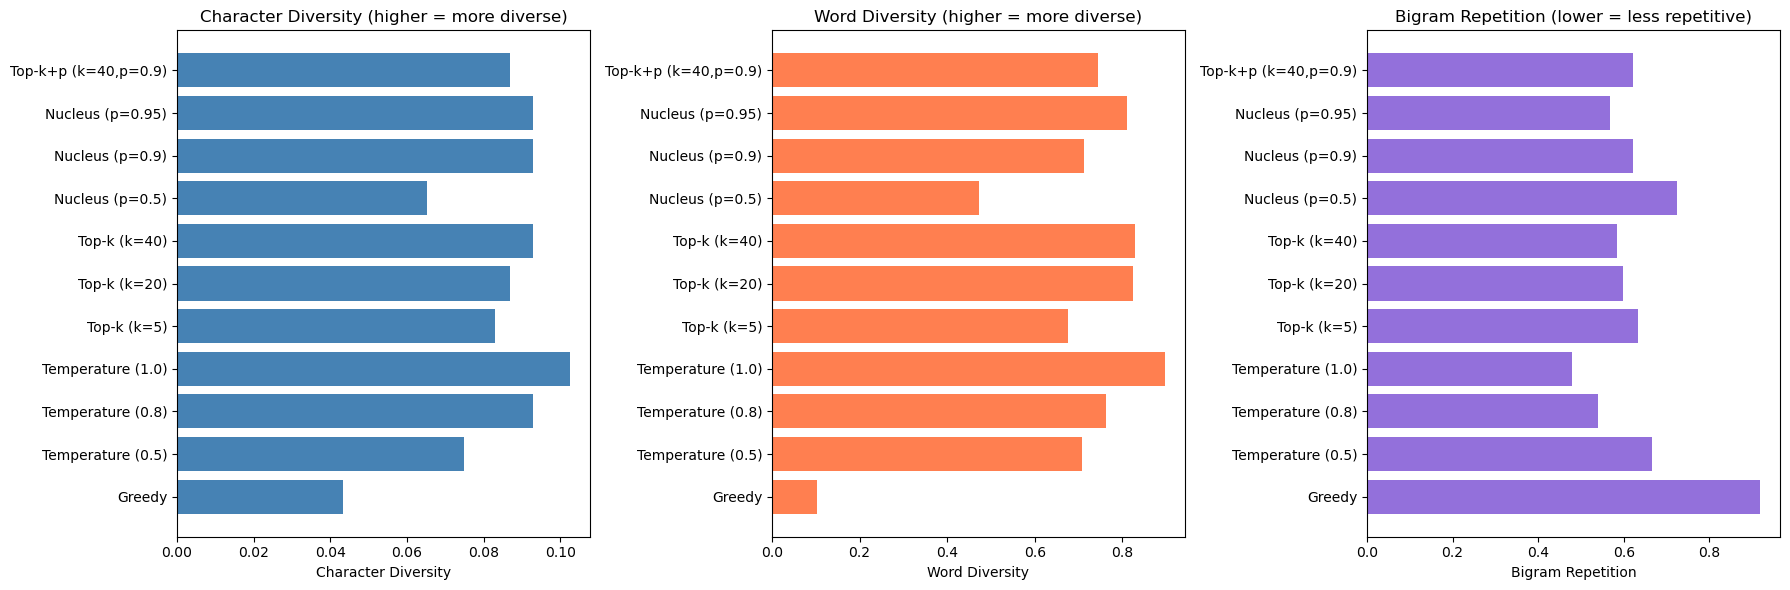

Saved: figures_bonus/sampling_metrics.png


In [3]:
# Visualize diversity metrics as bar chart
import matplotlib.pyplot as plt

names = [r['name'] for r in sampling_results]
char_div = [r['metrics']['char_diversity'] for r in sampling_results]
word_div = [r['metrics']['word_diversity'] for r in sampling_results]
bigram_rep = [r['metrics']['bigram_repetition'] for r in sampling_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].barh(names, char_div, color='steelblue')
axes[0].set_xlabel('Character Diversity')
axes[0].set_title('Character Diversity (higher = more diverse)')

axes[1].barh(names, word_div, color='coral')
axes[1].set_xlabel('Word Diversity')
axes[1].set_title('Word Diversity (higher = more diverse)')

axes[2].barh(names, bigram_rep, color='mediumpurple')
axes[2].set_xlabel('Bigram Repetition')
axes[2].set_title('Bigram Repetition (lower = less repetitive)')

plt.tight_layout()
plt.savefig('figures_bonus/sampling_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures_bonus/sampling_metrics.png')

---
## Bonus 2: LSTM Hidden State Visualization

Visualize what LSTM neurons learn to track:
- Heatmap of hidden/cell state activations
- Identify neurons correlated with specific patterns (newlines, uppercase, punctuation, etc.)

In [4]:
from lstm_visualization import run_full_visualization

# Use a representative Shakespeare passage
text_sample = dataset_shakespeare.raw_text[1000:1150]
print(f'Analyzing text:\n{text_sample}')
print(f'Length: {len(text_sample)} characters')

Analyzing text:
Second Citizen:
Would you proceed especially against Caius Marcius?

All:
Against him first: he's a very dog to the commonalty.

Second Citizen:
Consi
Length: 150 characters


Analyzing text (150 chars): Second Citizen:
Would you proceed especially against Caius M...

1. Hidden State Heatmap
Saved: figures_bonus/shakespeare_hidden_heatmap.png


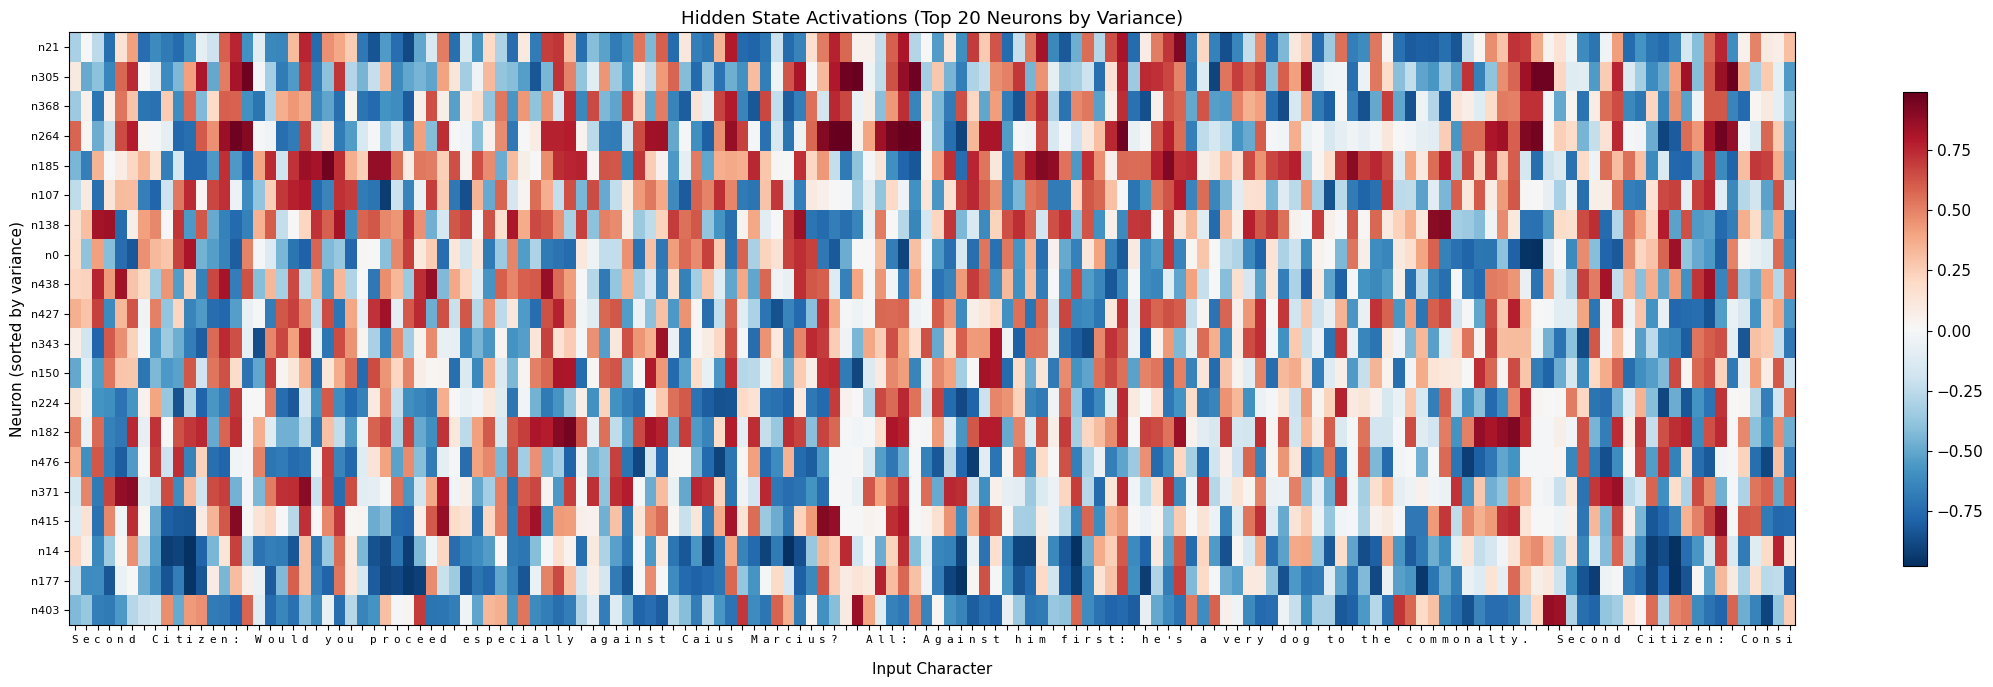


2. Cell State Heatmap
Saved: figures_bonus/shakespeare_cell_heatmap.png


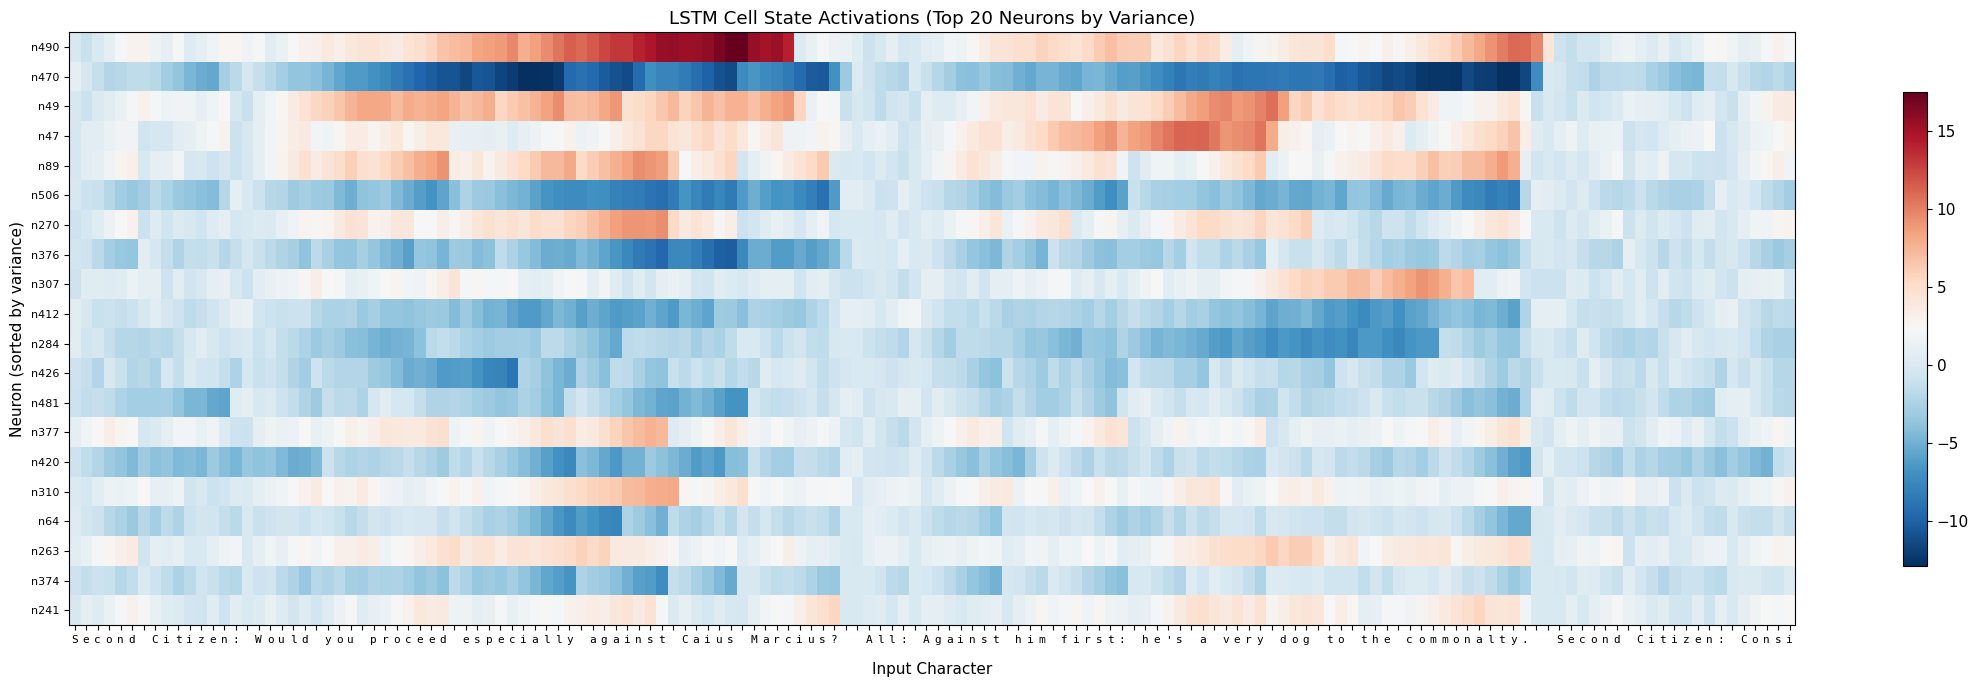


3. Pattern-Tracking Neurons
Saved: figures_bonus/shakespeare_pattern_neurons.png


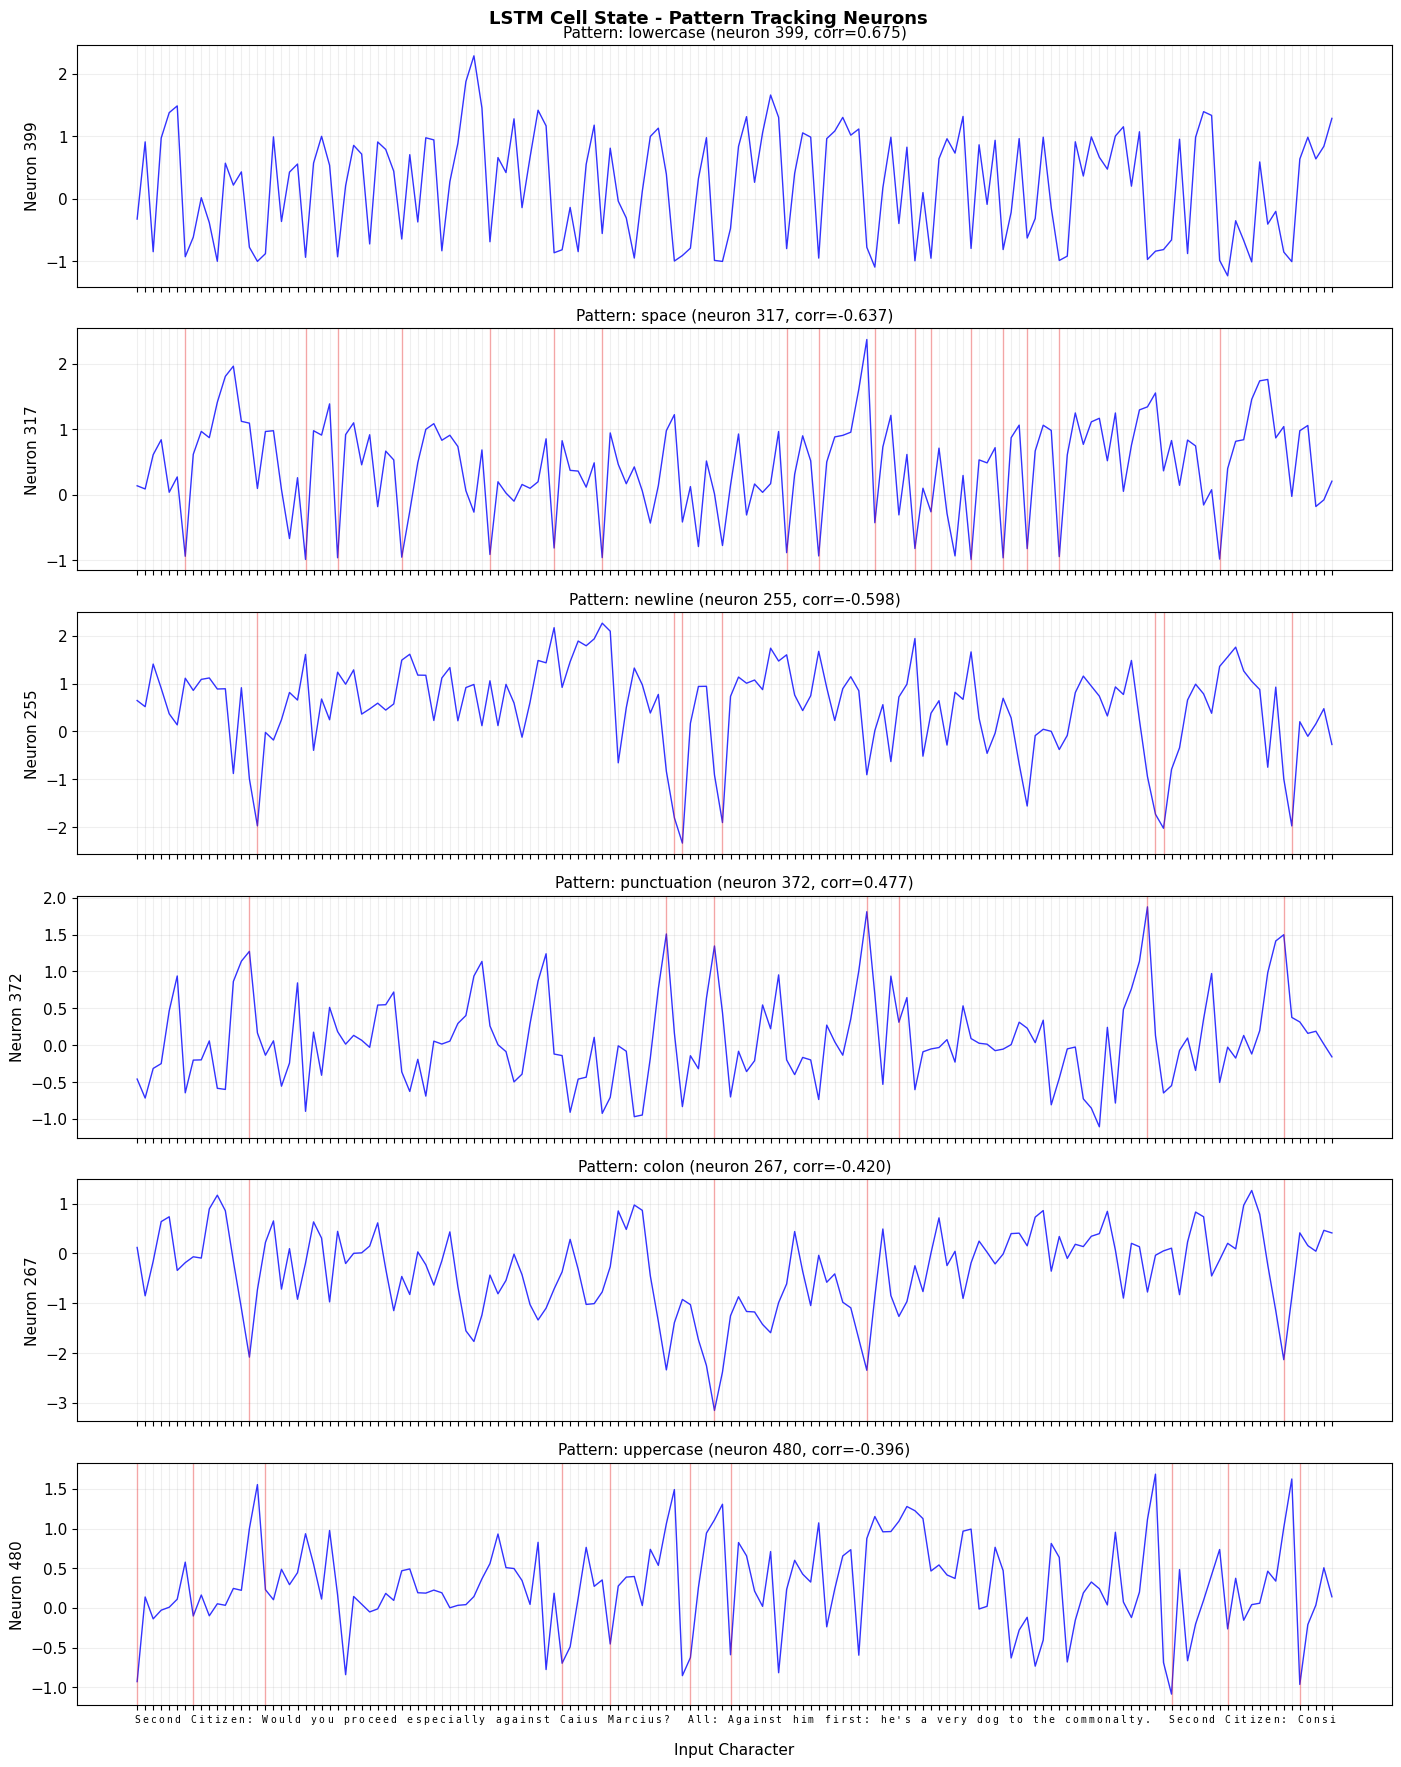


Pattern Neuron Summary:
Pattern         Neuron     Correlation 
-------------------------------------
lowercase       399        0.6753      
space           317        -0.6371     
newline         255        -0.5983     
punctuation     372        0.4770      
colon           267        -0.4200     
uppercase       480        -0.3960     

Visualization complete! Figures saved to figures_bonus/


In [5]:
run_full_visualization(
    model, dataset_shakespeare, device,
    text_sample=text_sample,
    save_dir='figures_bonus',
    prefix='shakespeare_'
)

### Shorter text for clearer heatmap (50 chars)

Short text: "Second Citizen:
Would you proceed especially against Caius M"
Saved: figures_bonus/cell_heatmap_short.png


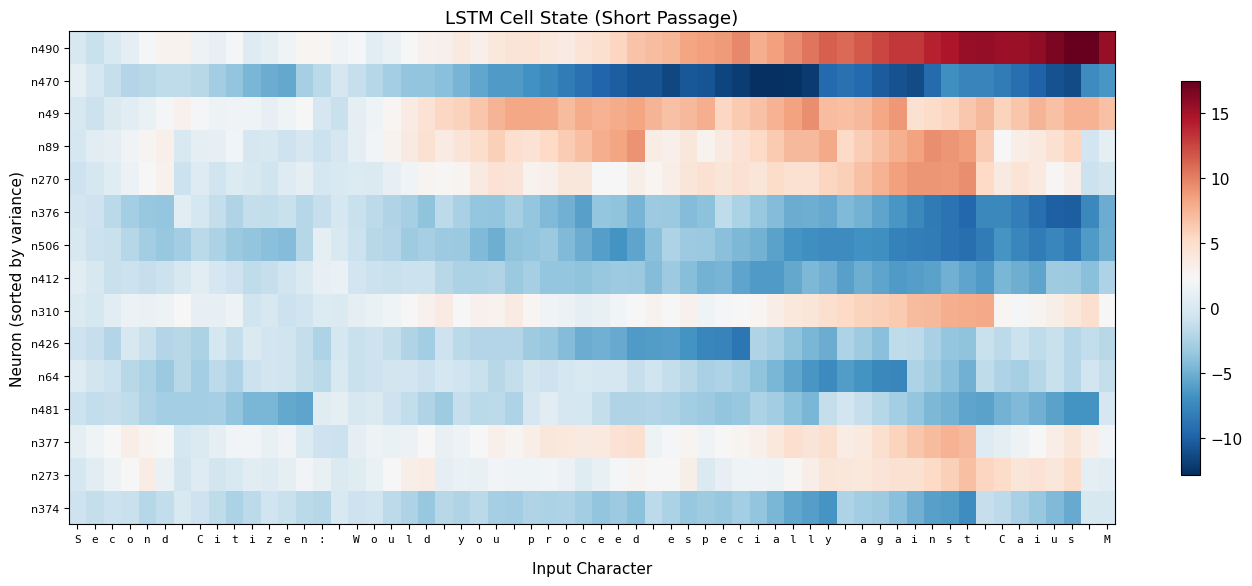

In [6]:
from lstm_visualization import record_hidden_states, plot_hidden_state_heatmap, plot_pattern_neurons

# Shorter passage for a cleaner, more readable heatmap
short_text = dataset_shakespeare.raw_text[1000:1060]
print(f'Short text: "{short_text}"')

record = record_hidden_states(model, dataset_shakespeare, short_text, device)

plot_hidden_state_heatmap(
    record, n_neurons=15, state_type='cell',
    title='LSTM Cell State (Short Passage)',
    save_path='figures_bonus/cell_heatmap_short.png'
)

---
## Bonus 3: Chinese Classical Poetry Dataset

Train CharRNN on Tang Dynasty poems and generate Chinese poetry.

In [8]:
import json, os

all_poems = []

json_files = [f for f in os.listdir('data') if f.startswith('poet.tang') and f.endswith('.json')]

for fname in sorted(json_files):
    with open(os.path.join('data', fname), 'r', encoding='utf-8') as f:
        poems = json.load(f)
        all_poems.extend(poems)
        print(f'{fname}: {len(poems)} poems')


lines = []
for poem in all_poems:
    title = poem.get('title', '')
    author = poem.get('author', '')
    paragraphs = poem.get('paragraphs', [])
    if not paragraphs:
        continue
    lines.append(title)
    lines.append(author)
    for line in paragraphs:
        lines.append(line)
    lines.append('')

text = '\n'.join(lines)
with open('data/chinese_poetry.txt', 'w', encoding='utf-8') as f:
    f.write(text)

print(f'\nTotal: {len(all_poems)} poems, {len(text)} chars')

poet.tang.0.json: 1000 poems
poet.tang.1000.json: 1000 poems
poet.tang.2000.json: 1002 poems
poet.tang.3000.json: 1001 poems
poet.tang.4000.json: 1000 poems
poet.tang.5000.json: 1000 poems
poet.tang.6000.json: 1001 poems
poet.tang.7000.json: 1003 poems
poet.tang.8000.json: 1001 poems
poet.tang.9000.json: 1000 poems

Total: 10008 poems, 853293 chars


In [9]:
poetry_path = 'data/chinese_poetry.txt'

In [11]:
# Create dataset
dataset_poetry = TextDataset('data/chinese_poetry.txt')

print(f'\nSample text:')
print(dataset_poetry.raw_text[:300])

Dataset: 853293 chars, 6114 unique
Train: 767963 chars, Val: 85330 chars

Sample text:
帝京篇十首 一
太宗皇帝
秦川雄帝宅，函谷壯皇居。
綺殿千尋起，離宮百雉餘。
連甍遙接漢，飛觀迥凌虛。
雲日隱層闕，風煙出綺疎。

帝京篇十首 二
太宗皇帝
巖廊罷機務，崇文聊駐輦。
玉匣啓龍圖，金繩披鳳篆。
韋編斷仍續，縹帙舒還卷。
對此乃淹留，欹案觀墳典。

帝京篇十首 三
太宗皇帝
移步出詞林，停輿欣武宴。
琱弓寫明月，駿馬疑流電。
驚雁落虛弦，啼猿悲急箭。
閱賞誠多美，於茲乃忘倦。

帝京篇十首 四
太宗皇帝
鳴笳臨樂館，眺聽歡芳節。
急管韻朱絃，清歌凝白雪。
彩鳳肅來儀，玄鶴紛成列。
去茲鄭衛聲，雅音方可悅。

帝京篇十首 五
太宗皇帝
芳辰追逸趣，禁苑信多奇。
橋形通漢上，峰勢接雲



Experiment 1/3: poetry_rnn
Config: model=rnn, hidden=256, layers=2, lr=0.002, dropout=0.2, opt=adam
Using device: cuda
Model parameters: 3,399,650
[1/2000] (0s) train_loss=8.7315 val_loss=8.4812 val_ppl=4823.28
  Sample: The 槨鬬磋恣婉窠閏酪諭縠朔耨巡絆眀氳偃周貪聞筌乖碎垠醜蠟蠁鴻愕俜璵輝}莅刎扁歟𨄳璽柢狐臾义禮噪檄莛藁恍頓葷渙錯皤雘莫姚鄰扶瀨討師鏡絢鍪鑷遒萑蓽贖旃一職評新諶...
[200/2000] (3s) train_loss=5.2584 val_loss=5.4783 val_ppl=239.43
  Sample: The 一和歌五首 一
地彥昂
披樹去水色。
覲軍四不識，一復照柳弦。
一春萬里月，俯衣雜波洽。

相和歌辭 將歌辭 主后
孟浩然
微海短羣水，嗷處流宇哉。

...
[400/2000] (6s) train_loss=4.7284 val_loss=5.1118 val_ppl=165.96
  Sample: The 十三
孟浩然
黃山初日雨，落花復何處。

題古李適
李白
南風一日落，白日誰相邇。

雜曲歌辭 二五州 三
劉長卿
語使人金人，山官如舊魂。
正期信書士...
[600/2000] (9s) train_loss=4.6217 val_loss=4.9621 val_ppl=142.89
  Sample: The 言第二五首 二
王維
禽尊朝騎道，龍駕山河好。
髣髴愁三天，朱弦向龍門。
虎輪出六俗，小女未淒驚。
一日偶歸日，今朝自作行。

奉和節使君使奉州聖
李頎...
[800/2000] (11s) train_loss=4.4057 val_loss=4.8875 val_ppl=132.62
  Sample: The 使君王少府
李白
我家高殿歸來有，都門一望流空流。

雜曲歌辭 思白首 二
李白
仙人綠壁上，天道從茲陪。

相和歌辭 祠中舞
顧況
物華賞兮盡有行，不...
[1000/2000] (14s) train_loss=4.3697 val_loss=4.8891 val_p

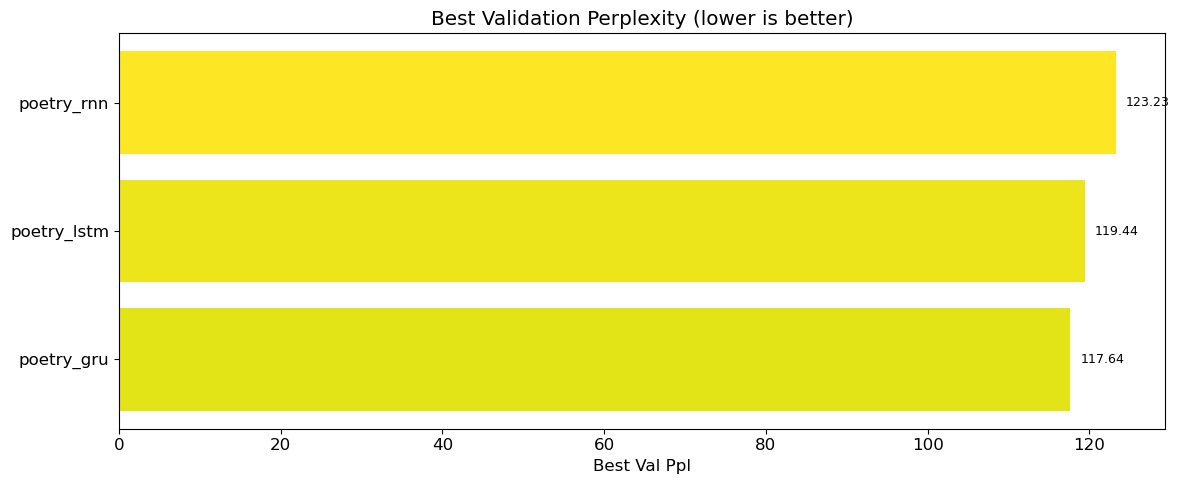

Saved: figures_poetry/summary_loss.png


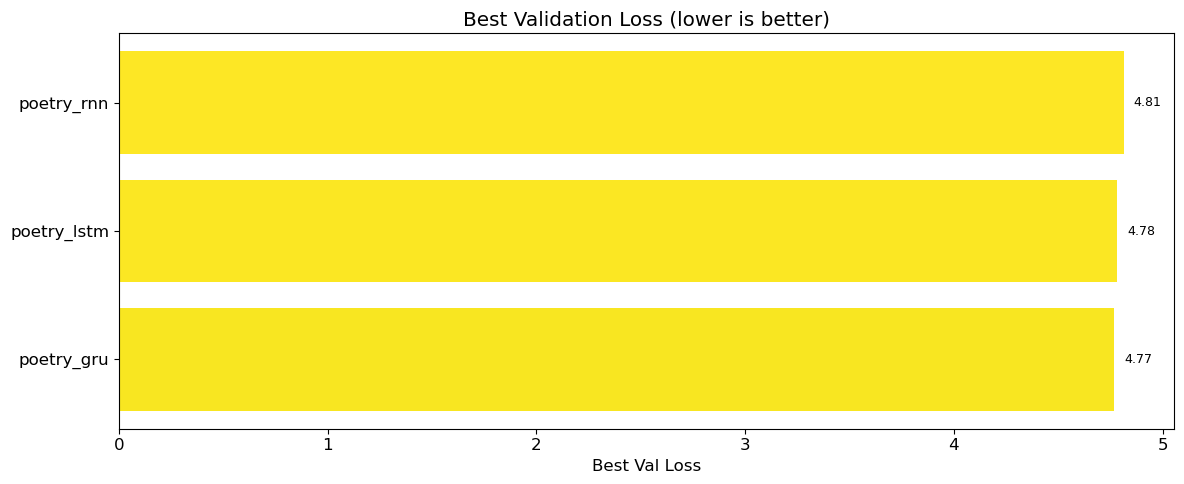

Saved: figures_poetry/training_time.png


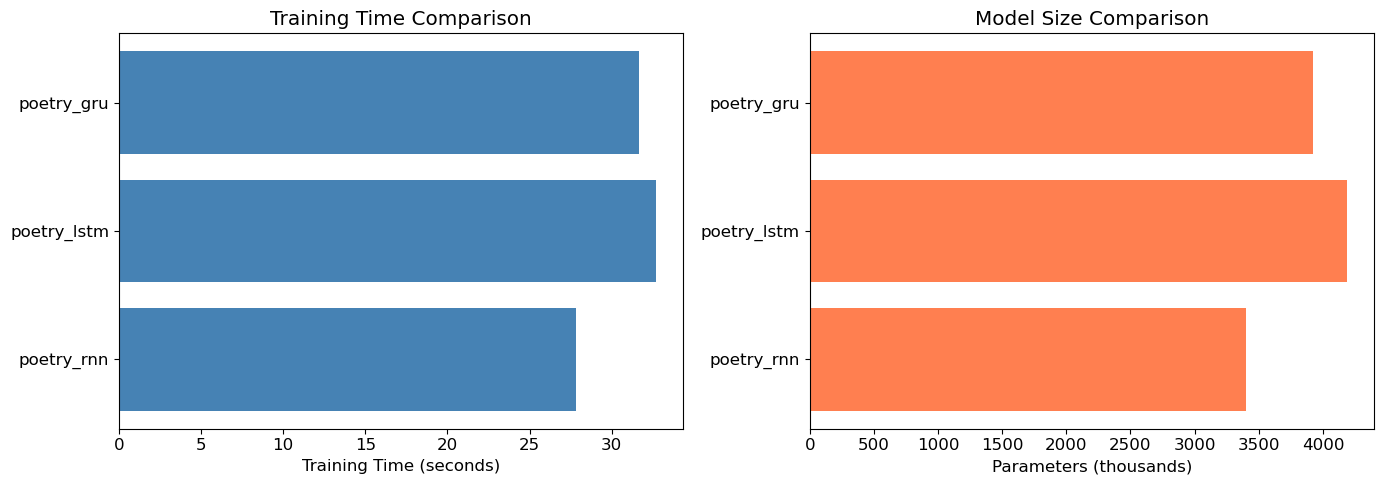


All figures saved to figures_poetry/


In [12]:
# Train model comparison on Chinese poetry (RNN vs LSTM vs GRU)
from run_experiments import run_experiment_grid
from visualize import generate_all_plots

poetry_experiments = []
base = {
    'n_epochs': 2000,
    'print_every': 200,
    'chunk_len': 100,     # shorter chunks for poetry (poems are short)
    'batch_size': 64,
    'hidden_size': 256,
    'n_layers': 2,
    'learning_rate': 0.002,
    'optimizer_type': 'adam',
    'dropout': 0.2,
}

for model_type in ['rnn', 'lstm', 'gru']:
    poetry_experiments.append({
        **base,
        'name': f'poetry_{model_type}',
        'model_type': model_type,
    })

results_poetry = run_experiment_grid(dataset_poetry, poetry_experiments, save_dir='results_poetry')
generate_all_plots(results_poetry, save_dir='figures_poetry')

In [13]:
# Generate Chinese poetry with best model
from generate import generate_samples_at_temperatures
from visualize import plot_temperature_samples

valid_poetry = [r for r in results_poetry if 'error' not in r]
best_poetry = min(valid_poetry, key=lambda r: r['best_val_loss'])
print(f'Best poetry model: {best_poetry["name"]}')

checkpoint_p = torch.load(best_poetry['config']['save_path'], map_location=device, weights_only=False)
model_poetry = CharRNN(
    input_size=dataset_poetry.n_characters,
    hidden_size=best_poetry['config']['hidden_size'],
    output_size=dataset_poetry.n_characters,
    model_type=best_poetry['config']['model_type'],
    n_layers=best_poetry['config']['n_layers'],
    dropout=best_poetry['config'].get('dropout', 0.0)
).to(device)
model_poetry.load_state_dict(checkpoint_p['model_state'])

# Generate with Chinese prime strings
poetry_samples = generate_samples_at_temperatures(
    model_poetry, dataset_poetry, device,
    prime_str='春',     # "Spring" - common poetry opening
    predict_len=200,
    temperatures=[0.2, 0.5, 0.8, 1.0, 1.5]
)
plot_temperature_samples(poetry_samples, save_path='figures_poetry/temperature_samples.txt')

Best poetry model: poetry_gru
TEXT SAMPLES AT DIFFERENT TEMPERATURES

--- Temperature = 0.2 ---
春。

送李侍御赴任
劉長卿
江上春風送，江山獨不歸。
江南秋月滿，江上送人歸。

送張十二赴任
劉長卿
江上人何在，江南送別離。
江南何處處，江上送君歸。

送別
劉長卿
江上潮江上，江南送別離。
江南江上柳，江上送人歸。

送張十二赴任
劉長卿
江上人不見，江南萬里愁。
江南江上月，江上送人稀。

送張十二赴江南
劉長卿
江上春風起，江南夕陽催。
江南江水闊，江上送人歸。
日暮江南客，江南送別離

--- Temperature = 0.5 ---
春。

奉和聖製送張說巡邊
張說
德和南山下，河連五馬間。
漢家朝典郡，萬里國夷迎。
天地生天地，文章舞馬來。
祥光隨海上，旌斾入雲雷。

奉和聖製幸臨渭亭登高應制得秋字
張說
千里年秋節，神仙作鳳皇。
雲間山上夜，煙月滿雲霞。

奉和聖製賜魏王昭臣
張說
金谷耀金殿，丹霞出紫宸。
高筵臨上苑，旌斾繞星辰。
今日陪仙閣，承恩賜綵旒。

奉和聖製幸臨渭山池應制
李乂
大道臨春水，神仙接鳳皇。
玉關臨水

--- Temperature = 0.8 ---
春。
望君關月夜，落日隔華空。

古意二首 二
李白
白日出赤墀，碧玉得長餐。
盤石金陵斑，蛾眉吐玉墀。
今日邊城斷，白露生青袍。
落日綠金閨，拂黛飜颼鳴。
不念之澄夜，隨來逐玉脂。

相和歌辭 妾思二首 二
張籍
春風搖入水，撩落玉壺中。
若在長門處，嬌歌送妾家。

輞川集二十首 九
儲光羲
高山今已久，遙共南山路。
山水路難分，桄榔望故鄉。
獨留山水闊，向挂南山潮。
思君汝山水，終滑能留客。



--- Temperature = 1.0 ---
春。

五雲出北侍登岱山亭
王維
中途文未外，早歲五秋秋。
壁散甘波上，幽源足乍疎。
魚藏棠篠嶺，溪散鷓鴣田。
樹接龍兵井，窗重數株林。
對餘簪組下，生事自忘科。

入天陰羽行
宋之問
西駕連南陌，龍旗隔鴻臺。
偃革雲雨歌飛相，還入天上紅塘花。
今得碧空雙洞牖，留山山裏尋王之。

奉和聖製送元度京都三賦得秦字
蘇頲
惜別風冬意，風吹動百秋。
締回陪河日，探重滿故臣。
先濫寒沙術，惟山此此歡。
洞庭來

--- Temperatur

In [14]:
# Try different prime strings
from generate import generate_text

prime_strings = ['月', '山', '風', '夜', '花']
# moon, mountain, wind, night, flower

print('='*60)
print('GENERATED CHINESE POETRY (Temperature=0.8)')
print('='*60)
for prime in prime_strings:
    text = generate_text(model_poetry, dataset_poetry,
                        prime_str=prime, predict_len=100,
                        temperature=0.8, device=device)
    print(f'\n--- Prime: {prime} ---')
    print(text)

GENERATED CHINESE POETRY (Temperature=0.8)

--- Prime: 月 ---
月三千里，邊中隴上千里去。
洛橋南渡湘城陲，古意不見死生髮。
世人山裏行疎遍，今年春酒且中歌。

雜曲歌辭 十九雉樂章 第三舞
不詳
新宗薦禮，寶祚神功。
重闕容衛，烝烝孝禮。
禮崇崇子，謙樂成功。
展

--- Prime: 山 ---
山桂涼。
何時伊陽里，獨立欲歸橈。

送友官赴河南
劉長卿

郊廟歌辭 祀九宮貴神樂章 迎俎酌迎八
儲光羲
九月三時，雲軿翹鳳。
氣清寶曆，玉帛中秩。
肅祥奠俎，歊俎斯。
載享惟德，祚五休盛。

郊廟歌

--- Prime: 風 ---
風然欲寄塗。

送張六事赴任西出從桃 三
李白
百年竟一老，近騁滄浪煙。
如何江上人，笑我醉中家。

送宋三陵
李白
郎人忽投贈，躞蹀白雲中。
我心無亦見，忽欲復來歸。
土氣蒼梧水，蕭然雨乾坤。
明時至

--- Prime: 夜 ---
夜，片日愁長安。
夜落江上夜，情如洞庭過。

送從弟幼妹兼寄去鄭襄陽
劉長卿
江南江月生，泛白雪田人。
自歲時人訪，飄颻不自茲。
今還依蕭索，歸去不歸人。

送王僕射光塘河
常建
吳陌遙江去，越王江上春

--- Prime: 花 ---
花下野風。
煙雲不可見，桃李下君春。

詠史
劉長卿
建章悲鐘鼓，先入玉臺中。
別影卷飛去，風塵新稍開。
更逢太清節，將取漢家人。

送李邕百
孟浩然
試問蓬萊月，山中獨在深。
春風發白日，旌旗斷候歌。


---
## Save All Bonus Results

In [15]:
import shutil

# Pack all bonus outputs
shutil.make_archive('bonus_results', 'zip', '.', 'figures_bonus')
shutil.make_archive('poetry_results', 'zip', '.', 'figures_poetry')
if os.path.exists('results_poetry'):
    shutil.make_archive('poetry_models', 'zip', '.', 'results_poetry')

print('Backup complete!')
print('  - bonus_results.zip   (sampling + visualization figures)')
print('  - poetry_results.zip  (Chinese poetry figures)')
print('  - poetry_models.zip   (Chinese poetry trained models)')

Backup complete!
  - bonus_results.zip   (sampling + visualization figures)
  - poetry_results.zip  (Chinese poetry figures)
  - poetry_models.zip   (Chinese poetry trained models)
